<a href="https://colab.research.google.com/github/DxubleBTW/averylee-lendingclub-loan-analysis/blob/main/averylee_lendingclub_loan_analysis_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LendingClub Loan Risk Analysis

### Columbia Data Science Research Program

**By: Avery Lee**

This project examines whether LendingClub loan grade and interest rate are associated with signs of repayment difficulty.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, chi2_contingency

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

In [5]:
url = "https://raw.githubusercontent.com/DxubleBTW/averylee-lendingclub-loan-analysis/refs/heads/main/lendingclub_loans_export.csv"

df = pd.read_csv(
    url,
    na_values=["NA", "", "N/A"]
)

df.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,0,38.0,2001,6,28,10,70795,38767,0,0,38.0,0,1250,2,5,5.0,10,0.0,0,2,11100,14,8,6,1,92.9,0,0,moving,individual,28000,60,14.07,652.53,C,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.0,14,0.0,0,3,16500,24,14,4,0,100.0,0,1,debt_consolidation,individual,5000,36,12.61,167.54,C,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,0,28.0,2006,4,31,10,24193,16000,0,0,28.0,0,432,1,13,7.0,10,0.0,0,3,4300,14,8,6,0,93.5,0,0,other,individual,2000,36,17.09,71.40,D,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.0,4,0.0,0,2,19400,3,3,2,0,100.0,1,0,debt_consolidation,individual,21600,36,6.72,664.19,A,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.0,16,0.0,0,10,32700,20,15,13,0,100.0,0,0,credit_card,joint,23000,36,14.07,786.87,C,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 55


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earli

In [8]:
df.sample(5, random_state=42)

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
6252,operation specialist,9.0,NC,RENT,65000.0,Verified,18.92,NaN,NaN,NaN,0,NaN,2004,3,9,9,107464,64183,0,0,NaN,0,0,1,7,2.0,9,0.0,0,4,46500,7,7,4,0,100.0,0,0,other,individual,10000,36,6.08,304.59,A,A2,Jan-2018,Current,whole,Cash,8717.45,1519.57,1282.55,237.02,0.0
4684,receptionist,1.0,CA,RENT,37000.0,Source Verified,13.17,NaN,NaN,NaN,0,43.0,2013,2,9,6,21700,13806,0,0,NaN,0,0,1,4,10.0,6,0.0,0,3,11800,6,5,3,1,100.0,0,0,debt_consolidation,individual,14400,36,15.04,499.47,C,C4,Feb-2018,Current,whole,Cash,13430.99,1486.38,969.01,517.37,0.0
1731,massage therapoist,10.0,NV,MORTGAGE,60000.0,Not Verified,5.10,NaN,NaN,NaN,1,14.0,2000,0,17,10,22838,10286,0,1,28.0,0,742,4,3,16.0,10,0.0,0,3,9300,10,6,5,0,29.4,0,1,debt_consolidation,individual,1200,36,15.04,41.63,C,C4,Mar-2018,Current,whole,Cash,1146.49,82.26,53.51,28.75,0.0
4742,senior software engineer,10.0,KS,MORTGAGE,100500.0,Source Verified,20.68,NaN,NaN,NaN,0,59.0,2000,6,43,22,149818,74764,0,0,NaN,0,0,3,5,2.0,22,0.0,0,9,75000,28,19,11,4,90.7,0,0,credit_card,individual,40000,60,7.96,810.30,A,A5,Mar-2018,Current,whole,DirectPay,38354.23,2395.52,1645.77,749.75,0.0
4521,executive director,5.0,LA,RENT,59000.0,Source Verified,1.02,NaN,NaN,NaN,0,36.0,2005,1,7,3,60921,63440,0,0,36.0,0,1687,1,3,9.0,3,0.0,0,2,1000,2,2,2,1,83.3,0,0,other,individual,7500,36,13.59,254.85,C,C2,Jan-2018,Current,whole,Cash,6630.98,1268.59,869.02,399.57,0.0


In [9]:
df.columns = (
    df.columns
      .str.lower()
      .str.strip()
      .str.replace(r"\s+", "_", regex=True)
)

df.columns.tolist()

['emp_title',
 'emp_length',
 'state',
 'homeownership',
 'annual_income',
 'verified_income',
 'debt_to_income',
 'annual_income_joint',
 'verification_income_joint',
 'debt_to_income_joint',
 'delinq_2y',
 'months_since_last_delinq',
 'earliest_credit_line',
 'inquiries_last_12m',
 'total_credit_lines',
 'open_credit_lines',
 'total_credit_limit',
 'total_credit_utilized',
 'num_collections_last_12m',
 'num_historical_failed_to_pay',
 'months_since_90d_late',
 'current_accounts_delinq',
 'total_collection_amount_ever',
 'current_installment_accounts',
 'accounts_opened_24m',
 'months_since_last_credit_inquiry',
 'num_satisfactory_accounts',
 'num_accounts_120d_past_due',
 'num_accounts_30d_past_due',
 'num_active_debit_accounts',
 'total_debit_limit',
 'num_total_cc_accounts',
 'num_open_cc_accounts',
 'num_cc_carrying_balance',
 'num_mort_accounts',
 'account_never_delinq_percent',
 'tax_liens',
 'public_record_bankrupt',
 'loan_purpose',
 'application_type',
 'loan_amount',
 'term'

In [10]:
text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].str.strip()

In [11]:
df.dtypes.value_counts()

,count
int64,25
float64,17
object,13


In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [13]:
df = df.drop_duplicates().copy()

In [14]:
missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)

missing_summary.head(15)

,missing_count,missing_percent
verification_income_joint,8545,85.45
annual_income_joint,8505,85.05
debt_to_income_joint,8505,85.05
months_since_90d_late,7715,77.15
months_since_last_delinq,5658,56.58
months_since_last_credit_inquiry,1271,12.71
emp_title,833,8.33
emp_length,817,8.17
num_accounts_120d_past_due,318,3.18
debt_to_income,24,0.24


In [15]:
df["application_type"].value_counts(dropna=False)

,count
application_type,
individual,8505
joint,1495


In [16]:
joint_missing_check = (
    df.groupby("application_type")[
        ["annual_income_joint", "debt_to_income_joint"]
    ]
    .apply(lambda x: x.isna().mean().mul(100))
    .round(2)
)

joint_missing_check

,annual_income_joint,debt_to_income_joint
application_type,,
individual,100.0,100.0
joint,0.0,0.0


In [17]:
print("Each row represents one loan.")
print("Each column represents one borrower, credit, or loan variable.")
print("The dataset is already in tidy format.")

Each row represents one loan.
Each column represents one borrower, credit, or loan variable.
The dataset is already in tidy format.


In [18]:
loan_status_counts = df["loan_status"].value_counts()

loan_status_counts

,count
loan_status,
Current,9375
Fully Paid,447
In Grace Period,67
Late (31-120 days),66
Late (16-30 days),38
Charged Off,7


In [19]:
df.to_csv(
    "cleaned_lendingclub_loans.csv",
    index=False
)

## Data Cleaning Summary
Column names were standardized, and extra spaces were removed from text values. Entries marked as “NA” were converted into missing values, and the dataset was checked for duplicate observations. No duplicate rows were found.

# Checkpoint 2: Exploratory Data Analysis

This section explores the distributions of important numerical and categorical variables, investigates extreme observations, and identifies possible relationships between borrower risk and repayment status.

In [20]:
numeric_summary = (
    df.select_dtypes(include=np.number)
      .describe()
      .T
)

numeric_summary

,count,mean,std,min,25%,50%,75%,max
emp_length,9183.0,5.930306,3.703734,0.00,2.0000,6.000,10.0000,1.000000e+01
annual_income,10000.0,79222.148412,64734.290492,0.00,45000.0000,65000.000,95000.0000,2.300000e+06
debt_to_income,9976.0,19.308192,15.004851,0.00,11.0575,17.570,25.0025,4.690900e+02
annual_income_joint,1495.0,127914.571244,70168.375404,19200.00,86833.5000,113000.000,151545.5000,1.100000e+06
debt_to_income_joint,1495.0,19.979304,8.054781,0.32,14.1600,19.720,25.5000,3.998000e+01
delinq_2y,10000.0,0.216000,0.683660,0.00,0.0000,0.000,0.0000,1.300000e+01
months_since_last_delinq,4342.0,36.760709,21.634939,1.00,19.0000,34.000,53.0000,1.180000e+02
earliest_credit_line,10000.0,2001.290000,7.795510,1963.00,1997.0000,2003.000,2006.0000,2.015000e+03
inquiries_last_12m,10000.0,1.958200,2.380130,0.00,0.0000,1.000,3.0000,2.900000e+01
total_credit_lines,10000.0,22.679600,11.885439,2.00,14.0000,21.000,29.0000,8.700000e+01


In [21]:
important_numeric_variables = [
    "annual_income",
    "debt_to_income",
    "loan_amount",
    "interest_rate",
    "installment",
    "delinq_2y",
    "inquiries_last_12m",
    "total_credit_limit",
    "total_credit_utilized"
]

df[important_numeric_variables].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
annual_income,10000.0,79222.15,64734.29,0.00,45000.00,65000.00,95000.00,2300000.00
debt_to_income,9976.0,19.31,15.00,0.00,11.06,17.57,25.00,469.09
loan_amount,10000.0,16361.92,10301.96,1000.00,8000.00,14500.00,24000.00,40000.00
interest_rate,10000.0,12.43,5.00,5.31,9.43,11.98,15.05,30.94
installment,10000.0,476.21,294.85,30.75,256.04,398.42,644.69,1566.59
delinq_2y,10000.0,0.22,0.68,0.00,0.00,0.00,0.00,13.00
inquiries_last_12m,10000.0,1.96,2.38,0.00,0.00,1.00,3.00,29.00
total_credit_limit,10000.0,183606.23,187632.71,0.00,51593.75,114667.00,267550.00,3386034.00
total_credit_utilized,10000.0,51049.06,53636.73,0.00,19185.50,36927.00,65421.00,942456.00


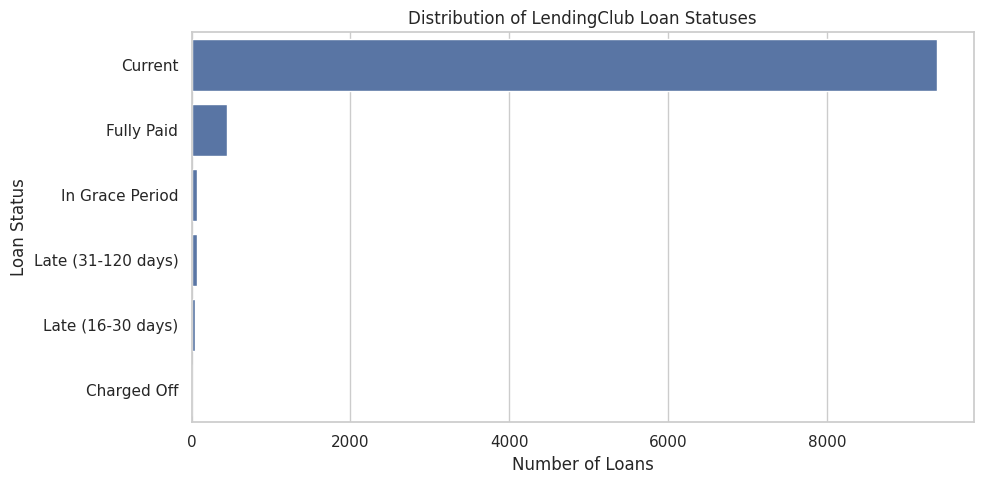

In [22]:
plt.figure(figsize=(10, 5))

status_order = df["loan_status"].value_counts().index

sns.countplot(
    data=df,
    y="loan_status",
    order=status_order
)

plt.title("Distribution of LendingClub Loan Statuses")
plt.xlabel("Number of Loans")
plt.ylabel("Loan Status")

plt.tight_layout()
plt.show()

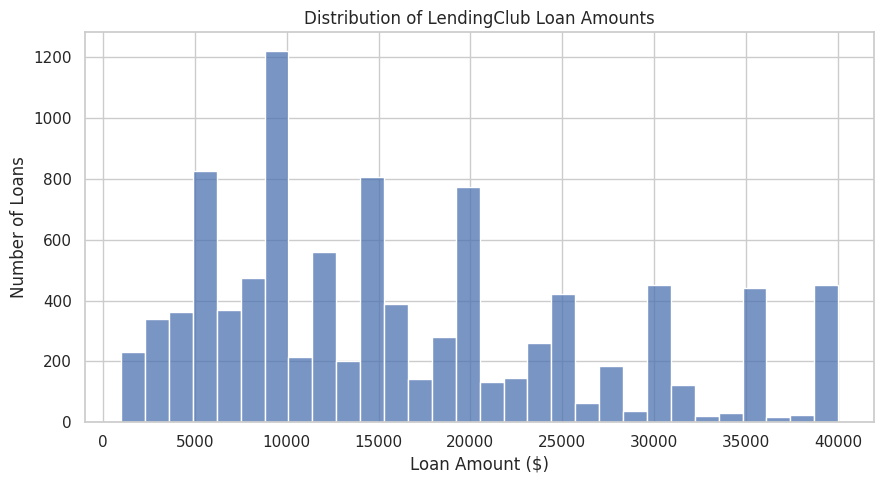

In [23]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="loan_amount",
    bins=30,
    edgecolor="white"
)

plt.title("Distribution of LendingClub Loan Amounts")
plt.xlabel("Loan Amount ($)")
plt.ylabel("Number of Loans")

plt.tight_layout()
plt.show()

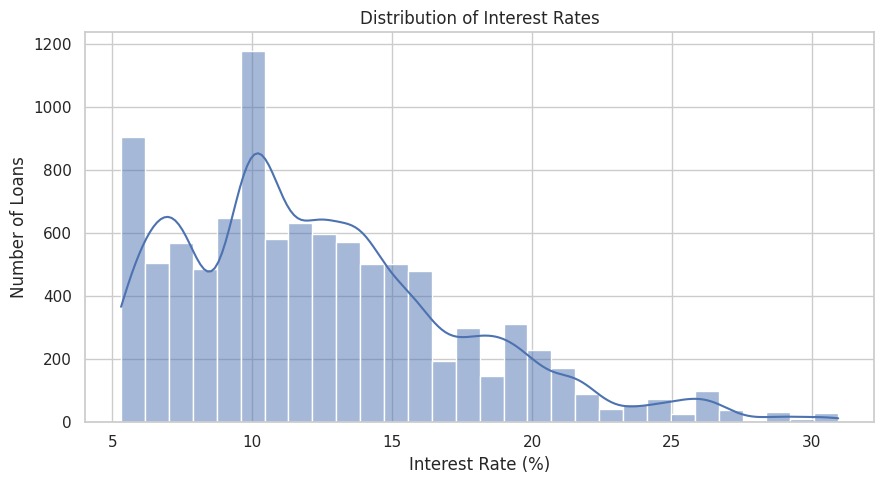

In [24]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="interest_rate",
    bins=30,
    kde=True
)

plt.title("Distribution of Interest Rates")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Number of Loans")

plt.tight_layout()
plt.show()

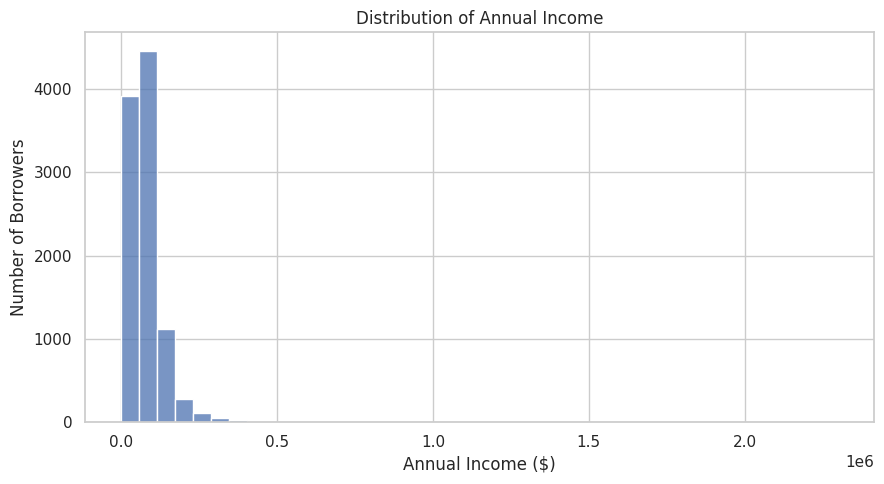

In [25]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="annual_income",
    bins=40
)

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income ($)")
plt.ylabel("Number of Borrowers")

plt.tight_layout()
plt.show()

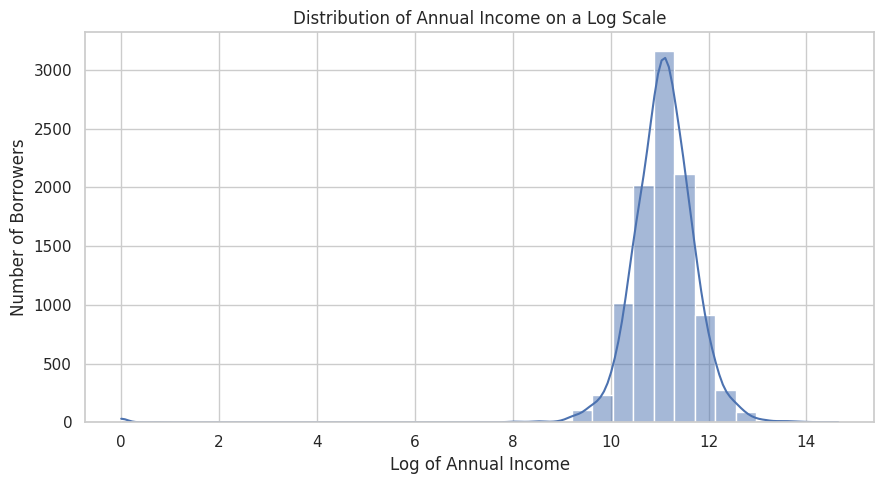

In [26]:
df["log_annual_income"] = np.log1p(df["annual_income"])

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="log_annual_income",
    bins=35,
    kde=True
)

plt.title("Distribution of Annual Income on a Log Scale")
plt.xlabel("Log of Annual Income")
plt.ylabel("Number of Borrowers")

plt.tight_layout()
plt.show()

In [27]:
outlier_variables = [
    "annual_income",
    "debt_to_income",
    "loan_amount",
    "interest_rate",
    "total_credit_limit",
    "total_credit_utilized"
]

for variable in outlier_variables:
    q1 = df[variable].quantile(0.25)
    q3 = df[variable].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (df[variable] < lower_bound) |
        (df[variable] > upper_bound)
    ).sum()

    print(
        variable,
        "| Lower bound:", round(lower_bound, 2),
        "| Upper bound:", round(upper_bound, 2),
        "| Outliers:", outlier_count
    )

annual_income | Lower bound: -30000.0 | Upper bound: 170000.0 | Outliers: 508
debt_to_income | Lower bound: -9.86 | Upper bound: 45.92 | Outliers: 221
loan_amount | Lower bound: -16000.0 | Upper bound: 48000.0 | Outliers: 0
interest_rate | Lower bound: 1.0 | Upper bound: 23.48 | Outliers: 364
total_credit_limit | Lower bound: -272340.62 | Upper bound: 591484.38 | Outliers: 351
total_credit_utilized | Lower bound: -50167.75 | Upper bound: 134774.25 | Outliers: 568


In [28]:
df[
    [
        "annual_income",
        "loan_amount",
        "interest_rate",
        "grade",
        "loan_status",
        "application_type"
    ]
].sort_values(
    "annual_income",
    ascending=False
).head(10)

,annual_income,loan_amount,interest_rate,grade,loan_status,application_type
9001,2300000.0,40000,9.44,B,Fully Paid,individual
3923,1600001.0,12000,7.34,A,Current,individual
9868,1200000.0,20000,5.31,A,Current,individual
4235,1050000.0,40000,6.72,A,Current,individual
726,1020000.0,20000,17.47,D,Current,individual
4414,910000.0,7000,7.34,A,Current,individual
2779,885000.0,7000,14.08,C,Current,individual
4874,793000.0,35000,18.06,D,Current,individual
6393,780000.0,12000,10.91,B,Current,individual
8243,780000.0,1000,10.41,B,Current,individual


In [29]:
df[
    [
        "annual_income",
        "annual_income_joint",
        "debt_to_income",
        "debt_to_income_joint",
        "application_type",
        "loan_amount",
        "loan_status"
    ]
].sort_values(
    "debt_to_income",
    ascending=False
).head(10)

,annual_income,annual_income_joint,debt_to_income,debt_to_income_joint,application_type,loan_amount,loan_status
516,3300.0,283300.0,469.09,9.79,joint,25000,Current
2185,4000.0,104000.0,437.61,22.48,joint,22000,Current
8688,5500.0,105500.0,315.94,34.31,joint,25800,Current
7231,5000.0,85000.0,267.55,29.93,joint,6000,Current
6799,5000.0,122200.0,216.83,16.67,joint,33600,Current
7034,3120.0,69120.0,215.38,9.72,joint,18000,Current
9318,19000.0,108820.0,209.10,36.50,joint,24000,Fully Paid
349,12000.0,152000.0,204.13,27.27,joint,29000,Current
5684,9972.0,78384.0,191.70,24.98,joint,20000,Current
3599,3000.0,33000.0,186.00,16.91,joint,5000,Current


In [30]:
categorical_variables = [
    "homeownership",
    "verified_income",
    "loan_purpose",
    "application_type",
    "term",
    "grade",
    "loan_status",
    "initial_listing_status",
    "disbursement_method"
]

for variable in categorical_variables:
    print(f"\n--- {variable} ---")
    print(df[variable].value_counts(dropna=False))


--- homeownership ---
homeownership
MORTGAGE    4789
RENT        3858
OWN         1353
Name: count, dtype: int64

--- verified_income ---
verified_income
Source Verified    4116
Not Verified       3594
Verified           2290
Name: count, dtype: int64

--- loan_purpose ---
loan_purpose
debt_consolidation    5144
credit_card           2249
other                  914
home_improvement       680
major_purchase         303
medical                162
house                  151
car                    131
small_business         125
moving                  69
vacation                62
renewable_energy        10
Name: count, dtype: int64

--- application_type ---
application_type
individual    8505
joint         1495
Name: count, dtype: int64

--- term ---
term
36    6970
60    3030
Name: count, dtype: int64

--- grade ---
grade
B    3037
C    2653
A    2459
D    1446
E     335
F      58
G      12
Name: count, dtype: int64

--- loan_status ---
loan_status
Current               9375
Fully Paid 

In [31]:
category_group_counts = (
    df[categorical_variables]
      .nunique()
      .sort_values(ascending=False)
      .to_frame("number_of_groups")
)

category_group_counts

,number_of_groups
loan_purpose,12
grade,7
loan_status,6
homeownership,3
verified_income,3
term,2
application_type,2
initial_listing_status,2
disbursement_method,2


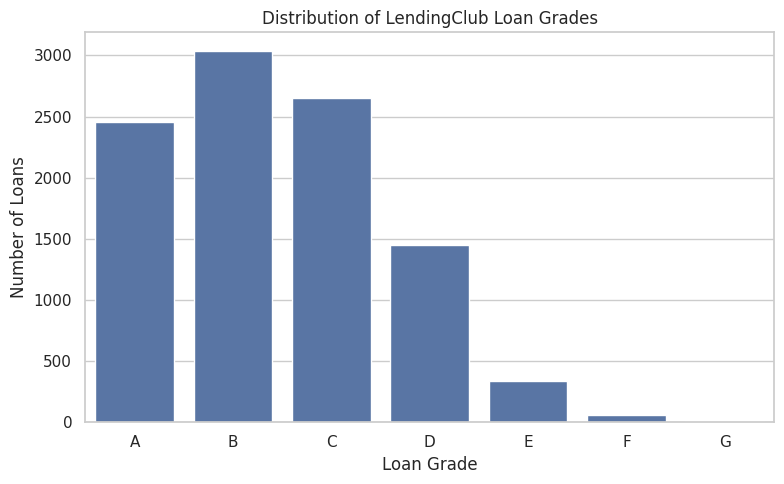

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="grade",
    order=list("ABCDEFG")
)

plt.title("Distribution of LendingClub Loan Grades")
plt.xlabel("Loan Grade")
plt.ylabel("Number of Loans")

plt.tight_layout()
plt.show()

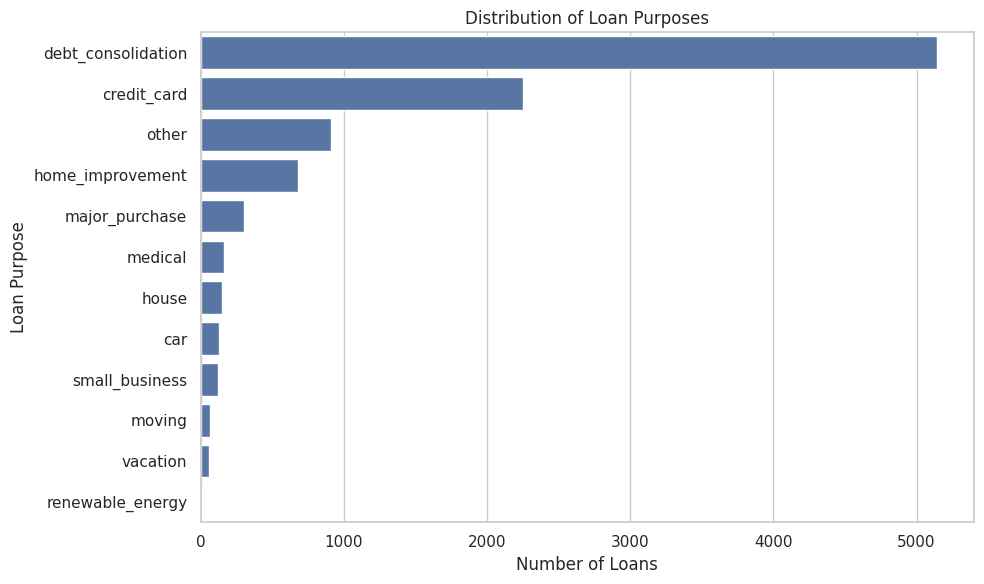

In [33]:
purpose_counts = df["loan_purpose"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=purpose_counts.values,
    y=purpose_counts.index
)

plt.title("Distribution of Loan Purposes")
plt.xlabel("Number of Loans")
plt.ylabel("Loan Purpose")

plt.tight_layout()
plt.show()

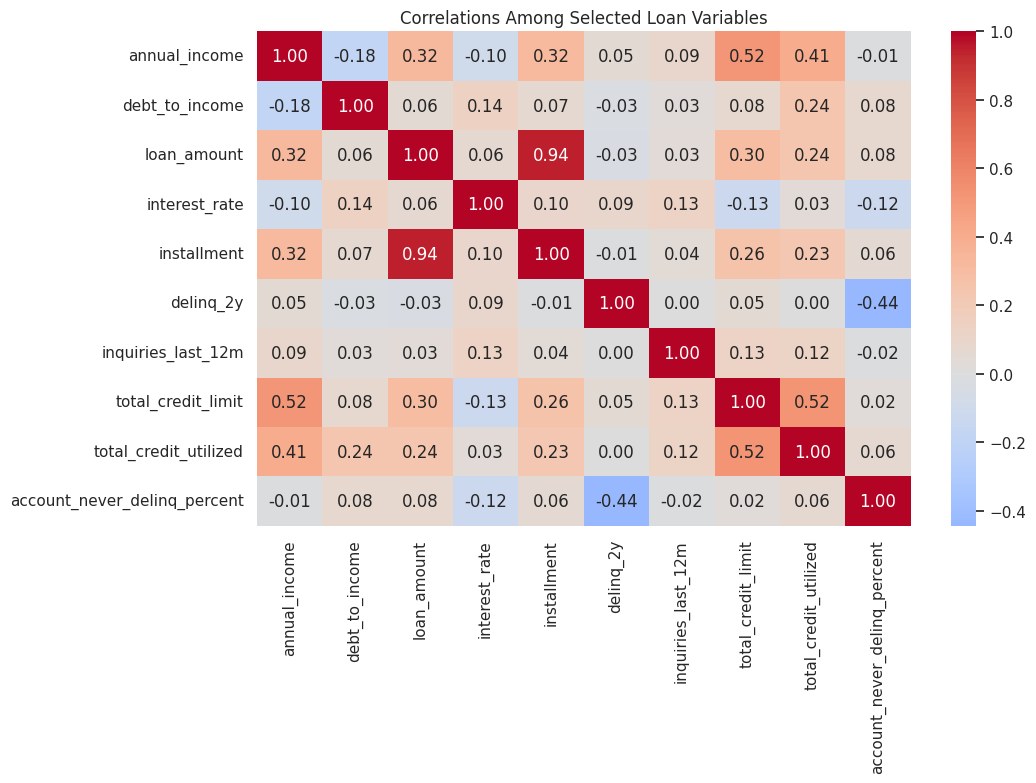

In [34]:
correlation_variables = [
    "annual_income",
    "debt_to_income",
    "loan_amount",
    "interest_rate",
    "installment",
    "delinq_2y",
    "inquiries_last_12m",
    "total_credit_limit",
    "total_credit_utilized",
    "account_never_delinq_percent"
]

correlation_matrix = df[correlation_variables].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlations Among Selected Loan Variables")

plt.tight_layout()
plt.show()

In [35]:
variation_summary = pd.DataFrame({
    "mean": df[important_numeric_variables].mean(),
    "standard_deviation": df[important_numeric_variables].std(),
    "coefficient_of_variation": (
        df[important_numeric_variables].std() /
        df[important_numeric_variables].mean().abs()
    )
}).sort_values(
    "coefficient_of_variation",
    ascending=False
)

variation_summary.round(3)

,mean,standard_deviation,coefficient_of_variation
delinq_2y,0.216,0.684,3.165
inquiries_last_12m,1.958,2.380,1.215
total_credit_utilized,51049.063,53636.731,1.051
total_credit_limit,183606.230,187632.708,1.022
annual_income,79222.148,64734.290,0.817
debt_to_income,19.308,15.005,0.777
loan_amount,16361.922,10301.957,0.630
installment,476.205,294.852,0.619
interest_rate,12.428,5.001,0.402


## Defining Payment Trouble

Only a very small number of loans are already charged off. Therefore, this analysis uses a broader indicator called “payment trouble,” which includes loans that are in a grace period, late, or charged off.

This variable represents current evidence of repayment difficulty, not confirmed default.

In [36]:
problem_statuses = [
    "In Grace Period",
    "Late (16-30 days)",
    "Late (31-120 days)",
    "Charged Off"
]

df["payment_trouble"] = (
    df["loan_status"]
      .isin(problem_statuses)
      .astype(int)
)

df["payment_trouble_label"] = df["payment_trouble"].map({
    0: "No Payment Trouble",
    1: "Payment Trouble"
})

df["payment_trouble_label"].value_counts()

,count
payment_trouble_label,
No Payment Trouble,9822
Payment Trouble,178


In [37]:
payment_trouble_percent = (
    df["payment_trouble"].mean() * 100
)

print(
    "Payment-trouble rate:",
    round(payment_trouble_percent, 2),
    "%"
)

Payment-trouble rate: 1.78 %


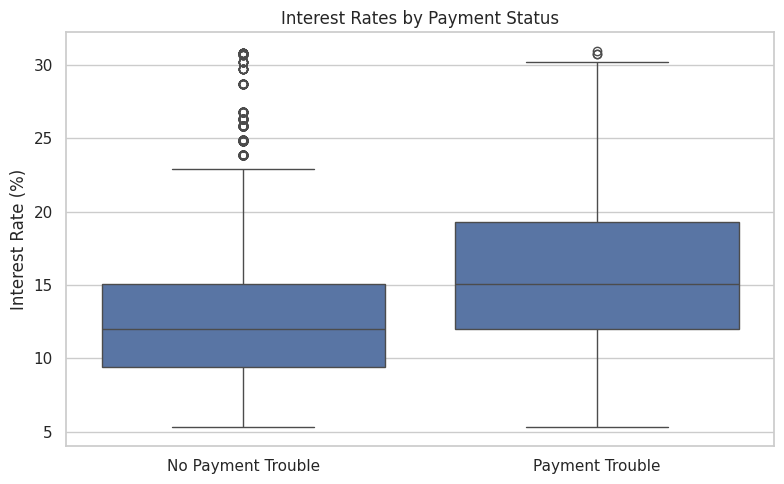

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="payment_trouble_label",
    y="interest_rate"
)

plt.title("Interest Rates by Payment Status")
plt.xlabel("")
plt.ylabel("Interest Rate (%)")

plt.tight_layout()
plt.show()

In [39]:
grade_trouble = (
    df.groupby("grade", observed=False)["payment_trouble"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

grade_trouble["payment_trouble_percent"] = (
    grade_trouble["mean"] * 100
)

grade_trouble

,grade,count,sum,mean,payment_trouble_percent
0,A,2459,19,0.007727,0.772672
1,B,3037,33,0.010866,1.086599
2,C,2653,52,0.019600,1.960045
3,D,1446,49,0.033887,3.388658
4,E,335,17,0.050746,5.074627
5,F,58,7,0.120690,12.068966
6,G,12,1,0.083333,8.333333


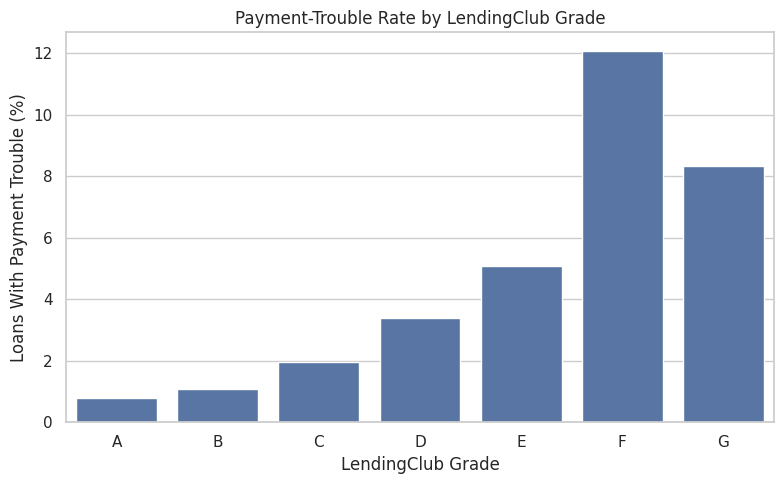

In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=grade_trouble,
    x="grade",
    y="payment_trouble_percent",
    order=list("ABCDEFG")
)

plt.title("Payment-Trouble Rate by LendingClub Grade")
plt.xlabel("LendingClub Grade")
plt.ylabel("Loans With Payment Trouble (%)")

plt.tight_layout()
plt.show()

# Checkpoint 3: Statistical Analysis

This section tests whether interest rate and LendingClub grade are statistically associated with payment trouble.

In [41]:
comparison_variables = [
    "interest_rate",
    "loan_amount",
    "annual_income",
    "debt_to_income",
    "delinq_2y",
    "inquiries_last_12m"
]

group_comparison = (
    df.groupby("payment_trouble_label")[comparison_variables]
      .agg(["count", "mean", "median", "std"])
      .round(2)
)

group_comparison

interest_rate                     loan_amount            \
                              count   mean median   std       count      mean   
payment_trouble_label                                                           
No Payment Trouble             9822  12.36  11.98  4.96        9822  16331.15   
Payment Trouble                 178  16.10  15.05  5.98         178  18059.97   

                                         annual_income                     \
                        median       std         count      mean   median   
payment_trouble_label                                                       
No Payment Trouble     14437.5  10292.52          9822  79149.78  65000.0   
Payment Trouble        15000.0  10703.30           178  83215.33  69176.5   

                                debt_to_income                      delinq_2y  \
                            std          count   mean median    std     count   
payment_trouble_label                                                           
No Payment Trouble     64649.34           9799  19.33  17.57  15.06      9822   
Payment Trouble        69337.64            177  18.01  17.16  11.37       178   

                                         inquiries_last_12m                     
                       mean median   std              count  mean median   std  
payment_trouble_label                                                           
No Payment Trouble     0.22    0.0  0.68               9822  1.95    1.0  2.37  
Payment Trouble        0.25    0.0  0.64                178  2.43    2.0  2.85

In [42]:
no_trouble_interest = df.loc[
    df["payment_trouble"] == 0,
    "interest_rate"
].dropna()

trouble_interest = df.loc[
    df["payment_trouble"] == 1,
    "interest_rate"
].dropna()

interest_test = mannwhitneyu(
    trouble_interest,
    no_trouble_interest,
    alternative="two-sided"
)

print(
    "No-payment-trouble mean:",
    round(no_trouble_interest.mean(), 2)
)

print(
    "Payment-trouble mean:",
    round(trouble_interest.mean(), 2)
)

print(
    "No-payment-trouble median:",
    round(no_trouble_interest.median(), 2)
)

print(
    "Payment-trouble median:",
    round(trouble_interest.median(), 2)
)

print(
    "Difference in means:",
    round(
        trouble_interest.mean() -
        no_trouble_interest.mean(),
        2
    )
)

print("Mann–Whitney U statistic:", interest_test.statistic)
print("P-value:", interest_test.pvalue)

No-payment-trouble mean: 12.36
Payment-trouble mean: 16.1
No-payment-trouble median: 11.98
Payment-trouble median: 15.05
Difference in means: 3.74
Mann–Whitney U statistic: 1206044.0
P-value: 3.386114030996092e-18


In [43]:
df["grade_group"] = df["grade"].replace({
    "E": "E-G",
    "F": "E-G",
    "G": "E-G"
})

grade_payment_table = pd.crosstab(
    df["grade_group"],
    df["payment_trouble"]
)

grade_payment_table

payment_trouble,0,1
grade_group,,
A,2440,19
B,3004,33
C,2601,52
D,1397,49
E-G,380,25


In [44]:
chi_square_result = chi2_contingency(
    grade_payment_table
)

chi2 = chi_square_result.statistic
grade_p_value = chi_square_result.pvalue
degrees_freedom = chi_square_result.dof
expected_counts = chi_square_result.expected_freq

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", degrees_freedom)
print("P-value:", grade_p_value)
print("Smallest expected count:", expected_counts.min())

Chi-square statistic: 89.22078081854197
Degrees of freedom: 4
P-value: 1.927602138200079e-18
Smallest expected count: 7.209


In [45]:
grade_percentage_table = pd.crosstab(
    df["grade_group"],
    df["payment_trouble"],
    normalize="index"
).mul(100).round(2)

grade_percentage_table.columns = [
    "No Payment Trouble (%)",
    "Payment Trouble (%)"
]

grade_percentage_table

,No Payment Trouble (%),Payment Trouble (%)
grade_group,,
A,99.23,0.77
B,98.91,1.09
C,98.04,1.96
D,96.61,3.39
E-G,93.83,6.17


In [46]:
no_trouble_amount = df.loc[
    df["payment_trouble"] == 0,
    "loan_amount"
].dropna()

trouble_amount = df.loc[
    df["payment_trouble"] == 1,
    "loan_amount"
].dropna()

loan_amount_test = mannwhitneyu(
    trouble_amount,
    no_trouble_amount,
    alternative="two-sided"
)

print(
    "Average amount, no payment trouble:",
    round(no_trouble_amount.mean(), 2)
)

print(
    "Average amount, payment trouble:",
    round(trouble_amount.mean(), 2)
)

print("P-value:", loan_amount_test.pvalue)

Average amount, no payment trouble: 16331.15
Average amount, payment trouble: 18059.97
P-value: 0.029608995026632393


In [47]:
grade_plot = (
    df.groupby("grade", observed=False)["payment_trouble"]
      .agg(["count", "sum", "mean"])
      .reindex(list("ABCDEFG"))
      .reset_index()
)

grade_plot["rate_percent"] = grade_plot["mean"] * 100

grade_plot["standard_error"] = np.sqrt(
    grade_plot["mean"] *
    (1 - grade_plot["mean"]) /
    grade_plot["count"]
)

grade_plot["error_95"] = (
    1.96 * grade_plot["standard_error"] * 100
)

grade_plot

,grade,count,sum,mean,rate_percent,standard_error,error_95
0,A,2459,19,0.007727,0.772672,0.001766,0.346091
1,B,3037,33,0.010866,1.086599,0.001881,0.368719
2,C,2653,52,0.019600,1.960045,0.002691,0.527499
3,D,1446,49,0.033887,3.388658,0.004758,0.932610
4,E,335,17,0.050746,5.074627,0.011991,2.350319
5,F,58,7,0.120690,12.068966,0.042775,8.383941
6,G,12,1,0.083333,8.333333,0.079786,15.637976


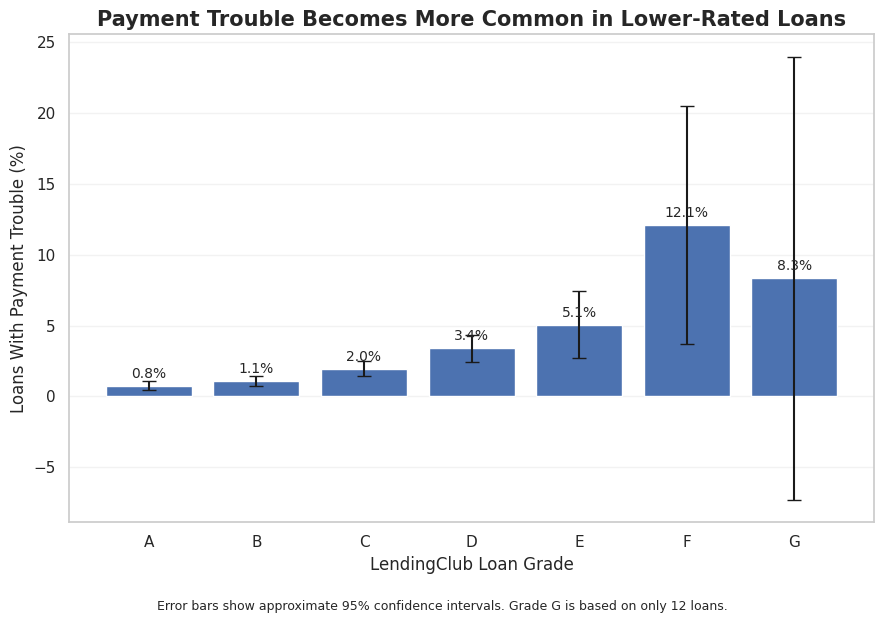

In [48]:
plt.figure(figsize=(9, 6))

bars = plt.bar(
    grade_plot["grade"],
    grade_plot["rate_percent"],
    yerr=grade_plot["error_95"],
    capsize=5
)

plt.title(
    "Payment Trouble Becomes More Common in Lower-Rated Loans",
    fontsize=15,
    weight="bold"
)

plt.xlabel("LendingClub Loan Grade", fontsize=12)
plt.ylabel("Loans With Payment Trouble (%)", fontsize=12)

plt.grid(axis="y", alpha=0.25)
plt.grid(axis="x", visible=False)

for bar, value in zip(bars, grade_plot["rate_percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.35,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.figtext(
    0.5,
    -0.03,
    "Error bars show approximate 95% confidence intervals. "
    "Grade G is based on only 12 loans.",
    ha="center",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "payment_trouble_by_grade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

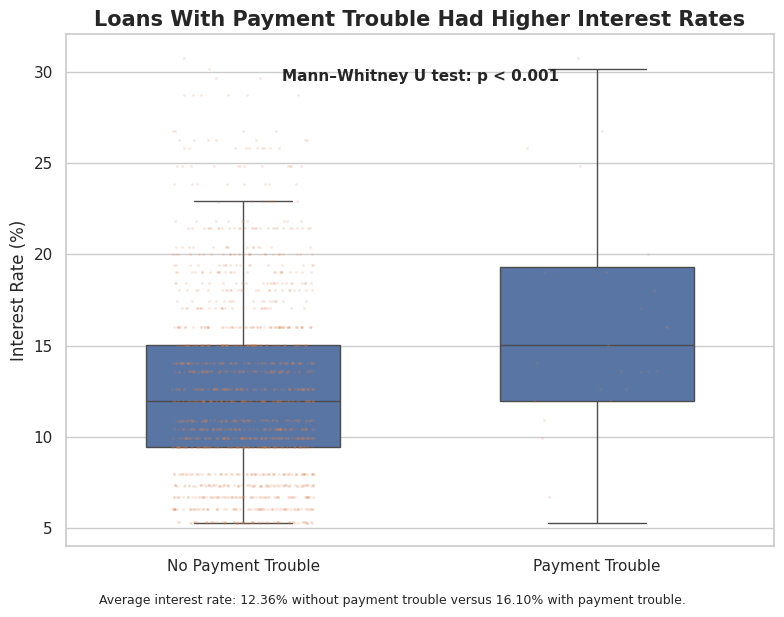

In [49]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="payment_trouble_label",
    y="interest_rate",
    width=0.55,
    showfliers=False
)

sns.stripplot(
    data=df.sample(
        min(1500, len(df)),
        random_state=42
    ),
    x="payment_trouble_label",
    y="interest_rate",
    alpha=0.18,
    jitter=0.2,
    size=2
)

plt.title(
    "Loans With Payment Trouble Had Higher Interest Rates",
    fontsize=15,
    weight="bold"
)

plt.xlabel("")
plt.ylabel("Interest Rate (%)", fontsize=12)

plt.text(
    0.5,
    29.5,
    "Mann–Whitney U test: p < 0.001",
    ha="center",
    fontsize=11,
    weight="bold"
)

plt.figtext(
    0.5,
    -0.02,
    "Average interest rate: 12.36% without payment trouble "
    "versus 16.10% with payment trouble.",
    ha="center",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "interest_rate_by_payment_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()